In [41]:
import cv2
import numpy as np
import glob
import matplotlib.pyplot as plt
import open3d as o3d 

## Camera Calibration

In [4]:
# Define the checkerboard's internal corner dimensions
chessboard_dims = (7, 9)  # (rows, columns) of inner corners
square_len = 15  # Square side length in millimeters or consistent units

# Generate the 3D reference coordinates for the checkerboard pattern (Z=0 plane)
object_3d = np.zeros((chessboard_dims[0] * chessboard_dims[1], 3), dtype=np.float32)
object_3d[:, :2] = np.mgrid[0:chessboard_dims[0], 0:chessboard_dims[1]].T.reshape(-1, 2)
object_3d *= square_len

# Initialize containers for 3D object points and corresponding 2D image points
object_points_left = []  # 3D world coordinates
image_points_left = []   # 2D image coordinates

# Acquire all PNG format images in the 'left' directory
left_images = glob.glob('left/*.png')

for img_path in left_images:
    image = cv2.imread(img_path)
    grayscale = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # Attempt to detect the internal corners of the checkerboard
    found, corners = cv2.findChessboardCorners(grayscale, chessboard_dims, None)

    if found:
        object_points_left.append(object_3d.copy())
        image_points_left.append(corners)

       

# Close all OpenCV windows if opened
cv2.destroyAllWindows()

# Calibrate the camera using the detected points from the left camera
ret, cam_matrix_left, dist_coeffs_left, rot_vecs_left, trans_vecs_left = cv2.calibrateCamera(
    object_points_left, image_points_left, grayscale.shape[::-1], None, None
)

# Calculate average reprojection error for left camera calibration
total_error = 0
for i in range(len(object_points_left)):
    projected_pts, _ = cv2.projectPoints(object_points_left[i], rot_vecs_left[i], trans_vecs_left[i],
                                         cam_matrix_left, dist_coeffs_left)
    error = cv2.norm(image_points_left[i], projected_pts, cv2.NORM_L2) / len(projected_pts)
    total_error += error

average_error = total_error / len(object_points_left)

# Output camera parameters and error for left camera
print("Camera Matrix1 (K1):\n", cam_matrix_left)
print("Distortion Coefficients1:\n", dist_coeffs_left.ravel())
print("Reprojection Error1:", average_error)

# Re-initialize object points using same configuration
object_3d = np.zeros((chessboard_dims[0] * chessboard_dims[1], 3), dtype=np.float32)
object_3d[:, :2] = np.mgrid[0:chessboard_dims[0], 0:chessboard_dims[1]].T.reshape(-1, 2)
object_3d *= square_len

# Reset containers for the right camera calibration
object_points_right = []
image_points_right = []

# Load images for right camera calibration
right_images = glob.glob('right/*.png')

for img_path in right_images:
    image = cv2.imread(img_path)
    grayscale = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # Identify checkerboard corners
    found, corners = cv2.findChessboardCorners(grayscale, chessboard_dims, None)

    if found:
        object_points_right.append(object_3d.copy())
        image_points_right.append(corners)


cv2.destroyAllWindows()

# Calibrate the right camera using the respective image set
ret_right, cam_matrix_right, dist_coeffs_right, rot_vecs_right, trans_vecs_right = cv2.calibrateCamera(
    object_points_right, image_points_right, grayscale.shape[::-1], None, None
)

# Compute reprojection error for right camera
total_error_right = 0
for i in range(len(object_points_right)):
    projected_pts, _ = cv2.projectPoints(object_points_right[i], rot_vecs_right[i], trans_vecs_right[i],
                                         cam_matrix_right, dist_coeffs_right)
    error = cv2.norm(image_points_right[i], projected_pts, cv2.NORM_L2) / len(projected_pts)
    total_error_right += error

average_error_right = total_error_right / len(object_points_right)

# Print calibration results for right camera
print("Camera Matrix (K2):\n", cam_matrix_right)
print("Distortion Coefficients2:\n", dist_coeffs_right.ravel())
print("Reprojection Error2:", average_error_right)


Camera Matrix1 (K1):
 [[1.11733489e+03 0.00000000e+00 6.33591415e+02]
 [0.00000000e+00 1.12105071e+03 3.52857415e+02]
 [0.00000000e+00 0.00000000e+00 1.00000000e+00]]
Distortion Coefficients1:
 [ 1.49600973e-01 -1.16724498e+00  2.06769613e-05  1.17632493e-03
  1.91543658e+00]
Reprojection Error1: 0.04115133280552776
Camera Matrix (K2):
 [[1.12791070e+03 0.00000000e+00 6.62008487e+02]
 [0.00000000e+00 1.12930803e+03 3.62094885e+02]
 [0.00000000e+00 0.00000000e+00 1.00000000e+00]]
Distortion Coefficients2:
 [ 0.11197568 -0.82377783 -0.00251442  0.00395234  0.93550175]
Reprojection Error2: 0.041811447380338776


## Stereo Calibration

In [7]:
# Ensure that required variables from the previous cell are available:
# - chessboard_dims
# - square_len
# - object_3d
# - K, dist (left intrinsics)
# - K1, dist1 (right intrinsics)
# - left_images, right_images

assert len(left_images) == len(right_images), "Number of left and right images must match"

# Containers for stereo calibration points
object_points = []         # 3D real-world points
left_image_points = []     # 2D points in left images
right_image_points = []    # 2D points in right images

# Process stereo image pairs
for l_path, r_path in zip(left_images, right_images):
    img_l = cv2.imread(l_path)
    img_r = cv2.imread(r_path)
    
    gray_l = cv2.cvtColor(img_l, cv2.COLOR_BGR2GRAY)
    gray_r = cv2.cvtColor(img_r, cv2.COLOR_BGR2GRAY)

    found_l, corners_l = cv2.findChessboardCorners(gray_l, chessboard_dims, None)
    found_r, corners_r = cv2.findChessboardCorners(gray_r, chessboard_dims, None)

    if found_l and found_r:
        object_points.append(object_3d)

        # Sub-pixel corner refinement
        criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 0.001)
        refined_l = cv2.cornerSubPix(gray_l, corners_l, (11, 11), (-1, -1), criteria)
        refined_r = cv2.cornerSubPix(gray_r, corners_r, (11, 11), (-1, -1), criteria)

        left_image_points.append(refined_l)
        right_image_points.append(refined_r)

cv2.destroyAllWindows()

# Stereo calibration
print("\nPerforming stereo calibration...")
flags = cv2.CALIB_FIX_INTRINSIC  # Fix intrinsics from individual calibrations

ret, K_left, D_left, K_right, D_right, R, T, E, F = cv2.stereoCalibrate(
    object_points, left_image_points, right_image_points,
    cam_matrix_left, dist_coeffs_left, cam_matrix_right, dist_coeffs_right,
    gray_l.shape[::-1],
    criteria=(cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 1e-5),
    flags=flags
)

# Output calibration results
print("\nStereo Calibration Results:")
print(f"Reprojection Error: {ret}")
print("\nLeft Camera Matrix (K1):\n", K_left)
print("\nLeft Distortion Coefficients (D1):\n", D_left)
print("\nRight Camera Matrix (K2):\n", K_right)
print("\nRight Distortion Coefficients (D2):\n", D_right)
print("\nRotation Matrix (R):\n", R)
print("\nTranslation Vector (T):\n", T)
print("\nEssential Matrix (E):\n", E)
print("\nFundamental Matrix (F):\n", F)

# Stereo rectification
print("\nComputing rectification parameters...")
R1, R2, P1, P2, Q, roi1, roi2 = cv2.stereoRectify(
    K_left, D_left, K_right, D_right, gray_l.shape[::-1], R, T, alpha=1
)

# Display rectification matrices
print("\nRectification Parameters:")
print("\nLeft Rectification Rotation (R1):\n", R1)
print("\nRight Rectification Rotation (R2):\n", R2)
print("\nLeft Projection Matrix (P1):\n", P1)
print("\nRight Projection Matrix (P2):\n", P2)
print("\nDisparity-to-Depth Mapping Matrix (Q):\n", Q)

# Save all relevant calibration outputs
print("\nSaving calibration results to stereo_calibration.npz...")
np.savez('stereo_calibration.npz',
         K1=K_left, D1=D_left, K2=K_right, D2=D_right,
         R=R, T=T, E=E, F=F,
         R1=R1, R2=R2, P1=P1, P2=P2, Q=Q)

print("\nStereo calibration complete!")



Performing stereo calibration...

Stereo Calibration Results:
Reprojection Error: 79.98705159542948

Left Camera Matrix (K1):
 [[1.11733489e+03 0.00000000e+00 6.33591415e+02]
 [0.00000000e+00 1.12105071e+03 3.52857415e+02]
 [0.00000000e+00 0.00000000e+00 1.00000000e+00]]

Left Distortion Coefficients (D1):
 [[ 1.49600973e-01 -1.16724498e+00  2.06769613e-05  1.17632493e-03
   1.91543658e+00]]

Right Camera Matrix (K2):
 [[1.12791070e+03 0.00000000e+00 6.62008487e+02]
 [0.00000000e+00 1.12930803e+03 3.62094885e+02]
 [0.00000000e+00 0.00000000e+00 1.00000000e+00]]

Right Distortion Coefficients (D2):
 [[ 0.11197568 -0.82377783 -0.00251442  0.00395234  0.93550175]]

Rotation Matrix (R):
 [[ 0.98112399 -0.07769717 -0.17708433]
 [ 0.09261369  0.99267554  0.07757564]
 [ 0.16975987 -0.09251175  0.98113361]]

Translation Vector (T):
 [[204.58598481]
 [-35.73314275]
 [187.88817044]]

Essential Matrix (E):
 [[ -23.4670707  -183.20625501  -49.63453234]
 [ 149.61110121    4.32822853 -233.99823633]

## Visualization of Undistorted Image

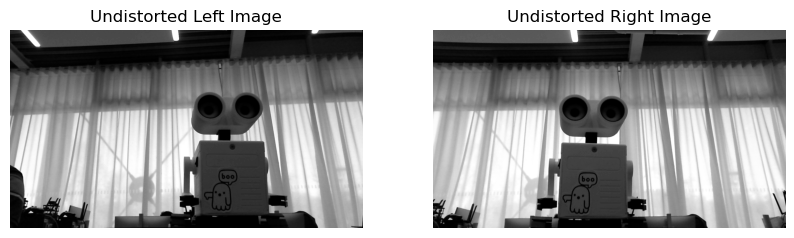

In [9]:
# Loading left and right images
left_img = cv2.imread("left.png")
right_img = cv2.imread("right.png")

# Convert to grayscale
left_gray = cv2.cvtColor(left_img, cv2.COLOR_BGR2GRAY)
right_gray = cv2.cvtColor(right_img, cv2.COLOR_BGR2GRAY)

# Undistort images
undistorted_left = cv2.undistort(left_gray, cam_matrix_left, dist_coeffs_left) # Removes distortion from an image using a precomputed camera matrix (K) and distortion coefficients.Corrects radial and tangential distortions caused by the camera lens, ensuring straight lines remain straight.
undistorted_right = cv2.undistort(right_gray, cam_matrix_right, dist_coeffs_right)

# Display the undistorted images
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(undistorted_left, cmap="gray")
plt.title("Undistorted Left Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(undistorted_right, cmap="gray")
plt.title("Undistorted Right Image")
plt.axis("off")

plt.show()


## Rectification

In [15]:
def rectify_images(img_left, img_right, K_left, D_left, K_right, D_right, transform):
    """
    Performs stereo image rectification using intrinsic parameters and a known transform.
    
    Parameters:
        img_left, img_right : input stereo images
        K_left, D_left      : intrinsics and distortion for left camera
        K_right, D_right    : intrinsics and distortion for right camera
        transform           : 4x4 transformation matrix [R|t]
    
    Returns:
        Rectified left and right images, and the disparity-to-depth matrix Q
    """
    # Decompose transformation matrix into rotation and translation components
    R = transform[:3, :3]
    t = transform[:3, 3]

    # Compute rectification transforms and projection matrices
    R1, R2, P1, P2, Q, _, _ = cv2.stereoRectify(
        K_left, D_left, K_right, D_right,
        img_left.shape[:2][::-1], R, t,
        flags=cv2.CALIB_ZERO_DISPARITY, alpha=1
    )

    print("\nProjection 1\n", P1)
    print("\nProjection 2\n", P2)

    # Generate remapping matrices for both images
    map1_x, map1_y = cv2.initUndistortRectifyMap(K_left, D_left, R1, P1, img_left.shape[:2][::-1], cv2.CV_32FC1)
    map2_x, map2_y = cv2.initUndistortRectifyMap(K_right, D_right, R2, P2, img_right.shape[:2][::-1], cv2.CV_32FC1)

    # Apply remapping to get rectified images
    rectified_left = cv2.remap(img_left, map1_x, map1_y, cv2.INTER_LINEAR)
    rectified_right = cv2.remap(img_right, map2_x, map2_y, cv2.INTER_LINEAR)

    return rectified_left, rectified_right, Q

def draw_epipolar_lines(image, color=(0, 255, 0), interval=20):
    """
    Overlay horizontal epipolar lines on a given image.

    Parameters:
        image : Input image to annotate
        color : BGR color for the lines
        interval : Vertical spacing between lines

    Returns:
        Image with epipolar lines
    """
    annotated = image.copy()
    height, width = image.shape[:2]
    for y in range(0, height, interval):
        cv2.line(annotated, (0, y), (width, y), color, 1)
    return annotated




Projection 1
 [[1.06434151e+03 0.00000000e+00 6.52331223e+02 0.00000000e+00]
 [0.00000000e+00 1.06434151e+03 3.56648308e+02 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 1.00000000e+00 0.00000000e+00]]

Projection 2
 [[1.06434151e+03 0.00000000e+00 6.52331223e+02 4.78953699e+01]
 [0.00000000e+00 1.06434151e+03 3.56648308e+02 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 1.00000000e+00 0.00000000e+00]]

Disparity to Depth Maping 'Q' Matrix
 [[ 1.00000000e+00  0.00000000e+00  0.00000000e+00 -6.52331223e+02]
 [ 0.00000000e+00  1.00000000e+00  0.00000000e+00 -3.56648308e+02]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  1.06434151e+03]
 [ 0.00000000e+00  0.00000000e+00 -2.22222213e+01  0.00000000e+00]]


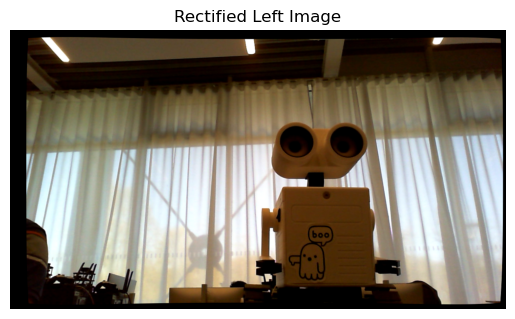

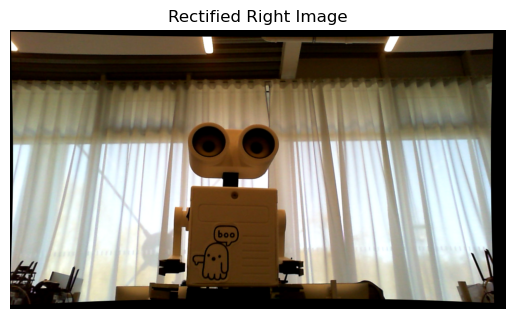

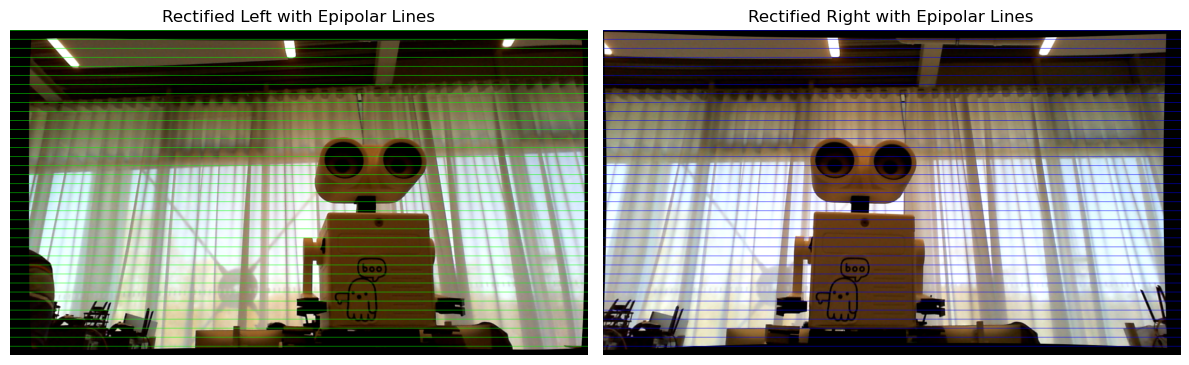

In [43]:
# Load stereo images
img_left = cv2.imread("left.png")
img_right = cv2.imread("right.png")

# Define transformation matrix (only translation in this simplified case)
T = np.eye(4, dtype=np.float32)
T[:3, 3] = np.array([0.045, 0, 0], dtype=np.float32)  # 4.5 cm baseline along X-axis

# Perform rectification using calibration results from the previous cell
rectified_left, rectified_right, Q = rectify_images(
    img_left, img_right, cam_matrix_left, dist_coeffs_left,
    cam_matrix_right, dist_coeffs_right, T
)

# Display the disparity-to-depth mapping matrix
print("\nDisparity to Depth Maping 'Q' Matrix\n",Q)

# Save rectified images for reference
cv2.imwrite('rectified_left.png', rectified_left)
cv2.imwrite('rectified_right.png', rectified_right)

# Visualize rectified images
plt.imshow(cv2.cvtColor(rectified_left, cv2.COLOR_BGR2RGB))
plt.title("Rectified Left Image")
plt.axis('off')
plt.show()

plt.imshow(cv2.cvtColor(rectified_right, cv2.COLOR_BGR2RGB))
plt.title("Rectified Right Image")
plt.axis('off')
plt.show()


# Add epipolar lines for visual verification
epipolar_left = draw_epipolar_lines(rectified_left, color=(0, 255, 0))
epipolar_right = draw_epipolar_lines(rectified_right, color=(255, 0, 0))

# Display epipolar line overlays side by side
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(epipolar_left, cv2.COLOR_BGR2RGB))
plt.title("Rectified Left with Epipolar Lines")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(epipolar_right, cv2.COLOR_BGR2RGB))
plt.title("Rectified Right with Epipolar Lines")
plt.axis('off')

plt.tight_layout()
plt.show()


##  Sparse Approach

In [ ]:
# Feature Detection and Matching 

# sift = cv2.SIFT_create()
# flann = cv2.FlannBasedMatcher()

# orb = cv2.ORB_create()
# bf_orb = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)

# surf = cv2.SURF_create()  # Updated SURF implementation
# bf = cv2.BFMatcher(cv2.NORM_L2, crossCheck=True)

# Feature Matching & Computing Essential Matrix, Rotation Matrices and Translation Matrix

Total matches found: 398
Total strong matches after filtering: 368
Fundamnetal Matrix [[ 2.42486708e-08 -1.98373359e-06  1.73949927e-03]
 [ 4.01892419e-06 -1.75360384e-06  2.81065944e-02]
 [-3.22242331e-03 -2.81755180e-02  1.00000000e+00]]
Rank of F: 2


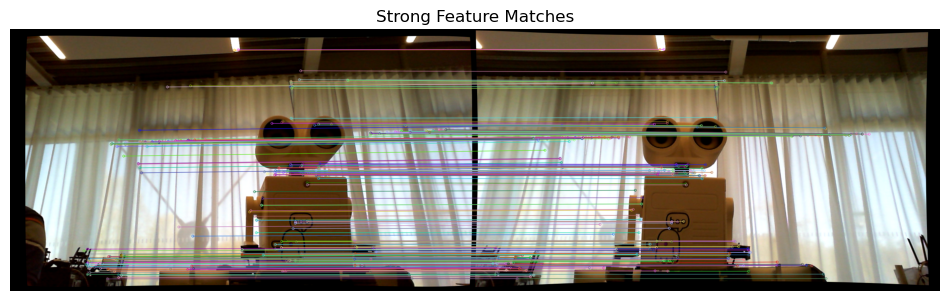

Essential Matrix:
[[ 3.02729438e-02 -2.48480300e+00  1.17866307e+00]
 [ 5.03406049e+00 -2.20384984e+00  3.36698367e+01]
 [-1.99885888e+00 -3.36888817e+01  2.82510189e-01]]

 Rotation Matrices:


Rotation Matrix R1
 [[-0.97069742  0.09150394  0.2222016 ]
 [ 0.09769263  0.99507146  0.01699821]
 [ 0.21955107 -0.03820758  0.97485256]]

Rotation Matrix R2
 [[-0.99643162  0.02774334  0.07971402]
 [-0.03001058 -0.99917434 -0.02738607]
 [-0.07888843  0.02968062 -0.99644151]]

Translation Vector:

[ 0.99686629 -0.03429869 -0.07128248]


In [25]:
# Initialize AKAZE detector and brute-force matcher (Hamming norm is suitable for binary descriptors)
akaze = cv2.AKAZE_create()
bf_matcher = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)

# Detect keypoints and compute descriptors in the rectified stereo images
keypoints_left, descriptors_left = akaze.detectAndCompute(rectified_left, None)
keypoints_right, descriptors_right = akaze.detectAndCompute(rectified_right, None)

# Match descriptors between the two images using brute-force matcher
initial_matches = bf_matcher.match(descriptors_left, descriptors_right)

# Sort matches based on descriptor distance (lower = better)
initial_matches = sorted(initial_matches, key=lambda x: x.distance)

# Filter out weak matches using a distance threshold
threshold = 100  # Matches with distance < threshold are considered strong
strong_matches = [m for m in initial_matches if m.distance < threshold]

# Display match statistics
print(f"Total matches found: {len(initial_matches)}")
print(f"Total strong matches after filtering: {len(strong_matches)}")

# Extract coordinates of matched keypoints
points_left = np.float32([keypoints_left[m.queryIdx].pt for m in strong_matches]).reshape(-1, 1, 2)
points_right = np.float32([keypoints_right[m.trainIdx].pt for m in strong_matches]).reshape(-1, 1, 2)

# Estimate the Fundamental matrix using RANSAC and filter inliers
F, inlier_mask = cv2.findFundamentalMat(points_left, points_right, cv2.FM_RANSAC, ransacReprojThreshold=3)
print('Fundamnetal Matrix', F)
print("Rank of F:", np.linalg.matrix_rank(F))

# Extract only inlier matches based on the mask
points_left_inliers = points_left[inlier_mask.ravel() == 1]
points_right_inliers = points_right[inlier_mask.ravel() == 1]

# Visualize matches with inliers highlighted
matched_image = cv2.drawMatches(
    rectified_left, keypoints_left, rectified_right, keypoints_right,
    strong_matches, None, matchesMask=inlier_mask.ravel().tolist(),
    flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
)

# Display the result
plt.figure(figsize=(12, 6))
plt.imshow(cv2.cvtColor(matched_image, cv2.COLOR_BGR2RGB))
plt.title("Strong Feature Matches")
plt.axis("off")
plt.show()

# Save the image with matched inliers
cv2.imwrite("strong_feature_matches_with_ransac.jpg", matched_image)

# Compute the Essential matrix using the known intrinsic camera matrix
E = cam_matrix_left.T @ F @ cam_matrix_left
print("Essential Matrix:")
print(E)

# Decompose the Essential matrix to retrieve rotation and translation (up to scale)
U, S, Vt = np.linalg.svd(E)
W = np.array([[0, -1, 0], [1, 0, 0], [0, 0, 1]])

# Two possible rotation matrices
R1_candidate = U @ W @ Vt
R2_candidate = U @ W.T @ Vt
translation_vector = U[:, 2]

# Output possible motion configurations
print("\n Rotation Matrices:\n")
print("\nRotation Matrix R1\n", R1_candidate)
print("\nRotation Matrix R2\n",R2_candidate)
print("\nTranslation Vector:\n")
print(translation_vector)


## Aplying Checks

In [26]:
# Perform Singular Value Decomposition on the Essential matrix
U, S, Vt = np.linalg.svd(E)
print(f"Singular values of E: {S}")

# Validate the rank condition of the Essential matrix
if np.isclose(S[2], 0, atol=1e-5):
    print("Essential matrix has the correct rank (2).")
else:
    print("Essential matrix does NOT have the correct rank!")

# Check the determinant condition of the Essential matrix
det_E = np.linalg.det(E)
print(f"Det(E) = {det_E}")
if np.isclose(det_E, 0, atol=1e-5):
    print("Essential matrix satisfies det(E) = 0 condition.")
else:
    print("Essential matrix does NOT satisfy det(E) = 0 condition!")

# Verify that candidate rotation matrices are valid (determinant should be +1)
det_R1 = np.linalg.det(R1_candidate)
det_R2 = np.linalg.det(R2_candidate)
print(f"Det(R1) = {det_R1}, Det(R2) = {det_R2}")


Singular values of E: [3.51091513e+01 3.28296287e+01 5.64808782e-16]
Essential matrix has the correct rank (2).
Det(E) = -1.3934286348326282e-13
Essential matrix satisfies det(E) = 0 condition.
Det(R1) = -0.9999999999999996, Det(R2) = -0.9999999999999996


## Triangulation

In [36]:
# Reuse cam_matrix_left as K (intrinsic matrix from left camera calibration)
K = cam_matrix_left

# Reuse decomposed essential matrix components
R1 = R1_candidate
R2 = R2_candidate
T = translation_vector

import cv2
import numpy as np

# Camera intrinsic matrix (replace with actual values)
K  # Replace with actual intrinsic matrix

# Essential matrix and decomposed values
E  
R1  
R2  
T  
# Check and fix T
print("Original T shape:", T.shape)
if T.shape == (3,):
    T = T.reshape(3, 1)
print("Fixed T shape:", T.shape)

# Choose the correct rotation matrix (closest to identity)
identity_matrix = np.eye(3)
R1_deviation = np.linalg.norm(R1 - identity_matrix)
R2_deviation = np.linalg.norm(R2 - identity_matrix)

if R1_deviation < R2_deviation:
    R = R1
    print("Selected R1")
else:
    R = R2
    print("Selected R2")

# Compute projection matrices
P1 = K @ np.hstack((np.eye(3), np.zeros((3, 1))))  # P1 = K [I | 0]
P2 = K @ np.hstack((R, T))  # P2 = K [R | T]

# Ensure points_left_inliers and points_right_inliers are 2D
print("points_left_inliers shape before reshape:", points_left_inliers.shape)
print("points_right_inliers shape before reshape:", points_right_inliers.shape)

if points_left_inliers.ndim == 3:
    points_left_inliers = points_left_inliers.reshape(-1, 2)
if points_right_inliers.ndim == 3:
    points_right_inliers = points_right_inliers.reshape(-1, 2)

# Convert points to homogeneous coordinates
points_left_inliers_hom = np.vstack((points_left_inliers.T, np.ones((1, points_left_inliers.shape[0]))))  # Shape: (3, N)
points_right_inliers_hom = np.vstack((points_right_inliers.T, np.ones((1, points_right_inliers.shape[0]))))  # Shape: (3, N)

# Perform triangulation
points_4d_hom = cv2.triangulatePoints(P1, P2, points_left_inliers_hom[:2], points_right_inliers_hom[:2])

# Convert from homogeneous to 3D coordinates
points_3d = points_4d_hom[:3] / points_4d_hom[3]  # Shape: (3, N)

# Filter out points with negative depth (Z should be positive)
valid_indices = points_3d[2] > 0
points_3d_filtered = points_3d[:, valid_indices]

# Print results
print("Reconstructed 3D Points (filtered):")
print(points_3d_filtered.T)  # Shape: (valid_N, 3)



Original T shape: (3,)
Fixed T shape: (3, 1)
Selected R1
points_left_inliers shape before reshape: (249, 2)
points_right_inliers shape before reshape: (249, 2)
Reconstructed 3D Points (filtered):
[[ 9.66109081e-01  6.24604579e-01  2.52048401e+00]
 [ 8.48025342e-01 -1.73154076e-01  2.14270634e+00]
 [ 8.19473068e-01 -1.62020517e-01  1.96574353e+00]
 [ 8.50107700e-01 -1.70412721e-01  2.15210766e+00]
 [ 8.47955650e-01 -1.74679369e-01  2.14255958e+00]
 [ 1.01432396e+00 -2.48006921e-01  3.17586285e+00]
 [ 8.57227903e-01 -1.69265180e-01  2.19252506e+00]
 [ 8.18966864e-01 -1.59942856e-01  1.96210047e+00]
 [ 8.71644950e-01 -1.82729057e-01  2.28731730e+00]
 [ 7.63386381e-01 -1.35585697e-01  1.60782336e+00]
 [ 9.98755015e-01  6.67333607e-01  2.69902439e+00]
 [ 8.30609362e-01 -1.95731101e-01  2.04345187e+00]
 [ 8.32796315e-01 -2.01414160e-01  2.06075233e+00]
 [ 1.01044272e+00 -2.44070658e-01  3.15479441e+00]
 [ 1.19589066e+00 -9.40034133e-01  4.54779326e+00]
 [ 7.29435924e-01 -1.19709663e-01  1.39

## Point Cloud

In [28]:
import open3d as o3d

# Load your point cloud
pcd = o3d.geometry.PointCloud()
pcd.points = o3d.utility.Vector3dVector(points_3d.T)  # Convert numpy to Open3D format

# Apply statistical outlier removal
pcd_filtered, ind = pcd.remove_statistical_outlier(nb_neighbors=20, std_ratio=2.0)

# Visualize before and after
o3d.visualization.draw_geometries([pcd], window_name="Noisy Point Cloud")
# o3d.visualization.draw_geometries([pcd_filtered], window_name="Filtered Point Cloud")

## Reprojection to Original Image

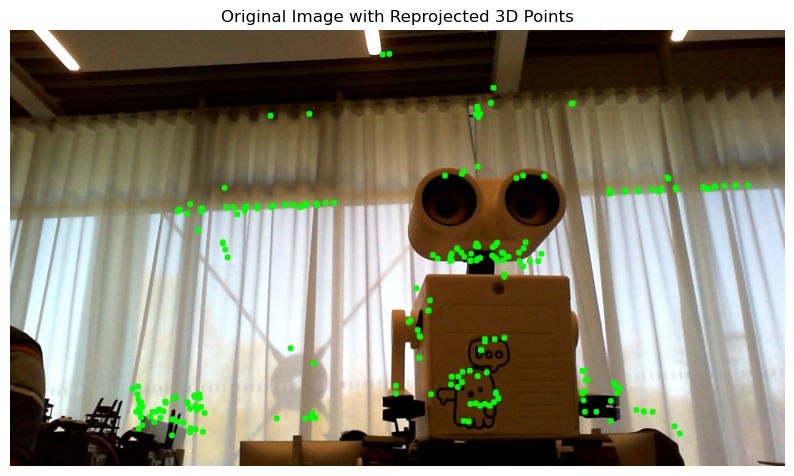

In [ ]:


# Assuming you already have the following:
# - points_3d: Reconstructed 3D points (shape: 3xN)
# - K: Camera intrinsic matrix
# - R, T: Rotation and translation between the two cameras
# - img1: Original first image (before rectification)

# Step 1: Define the projection matrix for the first camera
P1 = K @ np.hstack((np.eye(3), np.zeros((3, 1))))  # P1 = K [I | 0]

# Step 2: Reproject 3D points onto the first image
points_4d_hom = np.vstack((points_3d, np.ones((1, points_3d.shape[1]))))  # Convert to homogeneous coordinates
reprojected_pts = P1 @ points_4d_hom  # Project to 2D
reprojected_pts = reprojected_pts[:2] / reprojected_pts[2]  # Normalize to get (u, v) coordinates


# Step 3: Visualize the reprojected points on the original image
img1_with_points = img_left.copy()  # Make a copy of the original image

# Draw the reprojected points on the image
for pt in reprojected_pts.T:
    u, v = int(pt[0]), int(pt[1])  # Convert to integer pixel coordinates
    cv2.circle(img1_with_points, (u, v), radius=5, color=(0, 255, 0), thickness=-1)  # Green points

# Display the image with reprojected points
plt.figure(figsize=(10, 6))
plt.imshow(cv2.cvtColor(img1_with_points, cv2.COLOR_BGR2RGB))
plt.title("Original Image with Reprojected 3D Points")
plt.axis('off')
plt.show()

# Depth Estimation


Disparity to Depth Mapping 'Q' Matrix
 [[ 1.00000000e+00  0.00000000e+00  0.00000000e+00 -6.52331223e+02]
 [ 0.00000000e+00  1.00000000e+00  0.00000000e+00 -3.56648308e+02]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  1.06434151e+03]
 [ 0.00000000e+00  0.00000000e+00 -2.22222213e+01  0.00000000e+00]]


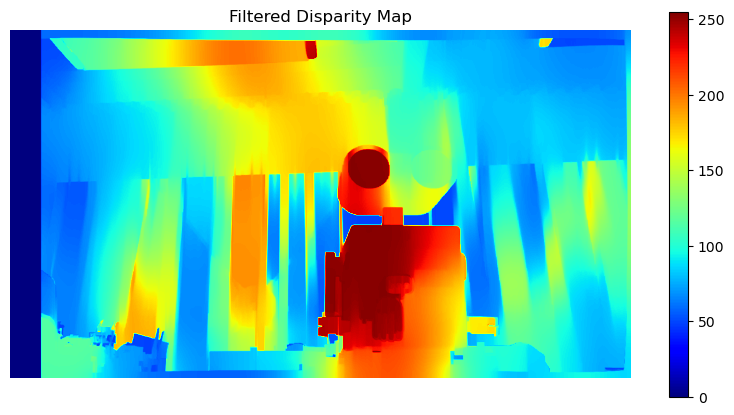

3D point cloud saved as output.ply


In [44]:


# Convert rectified left image to grayscale if needed (for stereo matching)
gray_left = cv2.cvtColor(rectified_left, cv2.COLOR_BGR2GRAY) if rectified_left.ndim == 3 else rectified_left
gray_right = cv2.cvtColor(rectified_right, cv2.COLOR_BGR2GRAY) if rectified_right.ndim == 3 else rectified_right

# Confirm Q matrix is available
print("\nDisparity to Depth Mapping 'Q' Matrix\n", Q)

# StereoSGBM parameters
min_disp = 0
num_disp = 16 * 4  # Must be divisible by 16
block_size = 11
stereo_sgbm = cv2.StereoSGBM_create(
    minDisparity=min_disp,
    numDisparities=num_disp,
    blockSize=block_size,
    uniquenessRatio=15,
    speckleWindowSize=100,
    speckleRange=32,
    disp12MaxDiff=1,
    preFilterCap=32,
    P1=8 * 3 * block_size**2,
    P2=32 * 3 * block_size**2,
    mode=cv2.STEREO_SGBM_MODE_HH
)

# Create right matcher for WLS filtering
right_matcher = cv2.ximgproc.createRightMatcher(stereo_sgbm)

# Compute raw disparity maps
disp_left = stereo_sgbm.compute(gray_left, gray_right).astype(np.float32) / 16.0
disp_right = right_matcher.compute(gray_right, gray_left).astype(np.float32) / 16.0

# Apply Weighted Least Squares (WLS) filter to refine disparity
wls = cv2.ximgproc.createDisparityWLSFilter(matcher_left=stereo_sgbm)
wls.setLambda(8000)
wls.setSigmaColor(2.5)
disp_filtered = wls.filter(disp_left, gray_left, disparity_map_right=disp_right)

# Normalize disparity map for visualization
disp_vis = cv2.normalize(disp_filtered, None, alpha=0, beta=255, norm_type=cv2.NORM_MINMAX)
disp_vis = np.uint8(disp_vis)

# Display the filtered disparity map
plt.figure(figsize=(10, 5))
plt.imshow(disp_vis, cmap='jet')
plt.colorbar()
plt.title("Filtered Disparity Map")
plt.axis('off')
plt.show()

# Convert disparity map to 3D coordinates using reprojection matrix Q
points_3d = cv2.reprojectImageTo3D(disp_filtered, Q)

# Generate mask for valid disparity values and finite coordinates
valid_mask = (disp_filtered > 10) & np.isfinite(points_3d[:, :, 0])
valid_points = points_3d[valid_mask]

# Get corresponding color values from original (rectified) left color image
colors = rectified_left[valid_mask]
colors = colors.astype(np.float32) / 255.0  # Normalize for Open3D

# Convert to Open3D PointCloud format
pcd = o3d.geometry.PointCloud()
pcd.points = o3d.utility.Vector3dVector(valid_points)
pcd.colors = o3d.utility.Vector3dVector(colors)

# Save and visualize the 3D point cloud
o3d.io.write_point_cloud("output.ply", pcd)
o3d.visualization.draw_geometries([pcd])

print("3D point cloud saved as output.ply")
